# Multiple Instance Learning on MNIST Bags
### Mark Sterkel, David Rath

This notebook implements and compares a multiple instance learning (MIL) model with three aggregation strategies on a synthetic MNIST bag dataset. We try to recreate the original setup of [Ilse et al. (2018)](https://arxiv.org/abs/1802.04712) as closely as possible, but with some slight modifications to the training.

In MIL, bags are sets of instances. A bag is positive if it contains at least one instance of the target digit (we chose the digit 9 here). Models are trained with only bag-level labels and evaluated on held-out test bags.

| **Aggregator** | **Test AUC** |
|----------------|:------------:|
| Mean pooling   |    0.9792    |
| Max pooling    |    0.9760    |
| ABMIL (gated attention) | **0.9920** |

The notebook is structured as follows:
1. MNIST Bags Dataset
2. Model
3. Training
4. Analysis & Visualisation

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.manifold import TSNE
import torch
import torch.nn as nn

In [2]:
# prepare some different paths
PROJECT_ROOT = '.'

DATA_DIR = f'{PROJECT_ROOT}/data'
CKPT_DIR  = f'{PROJECT_ROOT}/checkpoints'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

In [3]:
# check if MNIST is found in data directory
print(f"MNIST found: {os.path.exists(f'{DATA_DIR}/MNIST')}")

MNIST found: True


In [4]:
# seed everything
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


## MNIST Bags Dataset
Next we load the MNIST dataset in the MIL bag format. MnistBags is a custom Dataset class that allows us to easily create bags of MNIST digits. Additionally, we alternate between positive and negative bags for a balanced class distribution.

In [5]:
class MnistBags(Dataset):
    """MNIST with synthetic MIL bag construction. A bag is positive (label=1) iff it contains at least one instance of
    `target_number`. We alternate between positive / negative bags for a 50/50 class balance (same as in the ABMIL implementation).
    """

    # MNIST normalisation stats
    # taken from https://github.com/pytorch/examples/blob/acc295dc7b90714f1bf47f06004fc19a7fe235c4/mnist/main.py#L118
    _MEAN = 0.1307
    _STD  = 0.3081

    def __init__(
        self,
        root: str,
        train: bool = True,
        target_number: int = 9,
        mean_bag_length: int = 10,
        var_bag_length: int = 2,
        num_bags: int = 250,
        seed: int = 1,
        transform=None,
        download: bool = False,
    ):
        super().__init__()
        self.target_number  = target_number
        self.mean_bag_length = mean_bag_length
        self.var_bag_length  = var_bag_length
        self.num_bags        = num_bags

        if transform is None:
            transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((self._MEAN,), (self._STD,)),
            ])

        mnist = MNIST(root=root, train=train, transform=transform, download=download)
        loader = DataLoader(mnist, batch_size=len(mnist), shuffle=False)
        all_imgs, all_labels = next(iter(loader))   # load all the data at once into memory

        self._bags, self._bag_labels, self._instance_labels, self._instance_digit_labels = (
            self._build_bags(all_imgs, all_labels, seed)
        )

    def _build_bags(self, imgs, labels, seed):
        rng = np.random.default_rng(seed)
        n   = imgs.shape[0]
        labels_np      = labels.numpy()
        non_target_idx = np.where(labels_np != self.target_number)[0]

        bags, bag_labels, inst_labels, digit_labels = [], [], [], []
        next_positive = True   # to alternate between positive and negative bags

        for _ in range(self.num_bags):
            length = max(1, int(rng.normal(self.mean_bag_length, self.var_bag_length)))

            if next_positive:

                # resample until we get a bag that contains the target digit
                # dont make n too large or this might take some time!
                while True:
                    idx = rng.integers(0, n, size=length)
                    if (labels_np[idx] == self.target_number).any():
                        break
            else:
                # we draw only from the non-target indices to alawys get a negative bag
                idx = rng.choice(non_target_idx, size=length, replace=True)

            bag_imgs  = imgs[idx]                           # (length, 1, 28, 28)
            inst_lbl  = labels[idx] == self.target_number   # BoolTensor (length,)
            bag_lbl   = int(inst_lbl.any())

            bags.append(bag_imgs)
            inst_labels.append(inst_lbl)
            bag_labels.append(bag_lbl)
            digit_labels.append(labels[idx])                # LongTensor (length,) actual digit 0-9

            next_positive = not next_positive

        return bags, bag_labels, inst_labels, digit_labels

    def __len__(self) -> int:
        return self.num_bags

    def __getitem__(self, index: int):
        return (
            self._bags[index],           # FloatTensor (N, 1, 28, 28)
            self._bag_labels[index],     # int
            self._instance_labels[index] # BoolTensor (N,)
        )

In [6]:
TARGET_NUMBER  = 9
MEAN_BAG_LEN   = 10
VAR_BAG_LEN    = 2
NUM_BAGS_TRAIN = 200
NUM_BAGS_VAL   = 50
NUM_BAGS_TEST  = 50

EPOCHS                  = 200
LR                      = 5e-4
WEIGHT_DECAY            = 1e-4
EARLY_STOPPING_PATIENCE = 10

# the training, validation and test datasets are drawn with different seeds (same as in the ABMIL implementation)
train_ds = MnistBags(root=DATA_DIR, train=True,  target_number=TARGET_NUMBER,
                     mean_bag_length=MEAN_BAG_LEN, var_bag_length=VAR_BAG_LEN,
                     num_bags=NUM_BAGS_TRAIN, seed=1)
val_ds   = MnistBags(root=DATA_DIR, train=True,  target_number=TARGET_NUMBER,
                     mean_bag_length=MEAN_BAG_LEN, var_bag_length=VAR_BAG_LEN,
                     num_bags=NUM_BAGS_VAL,   seed=2)
test_ds  = MnistBags(root=DATA_DIR, train=False, target_number=TARGET_NUMBER,
                     mean_bag_length=MEAN_BAG_LEN, var_bag_length=VAR_BAG_LEN,
                     num_bags=NUM_BAGS_TEST,  seed=3)

# create the DataLoaders for training, validation and testing
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False)

for split, ds in [("Train", train_ds), ("Val  ", val_ds), ("Test ", test_ds)]:
    pos = sum(ds._bag_labels)
    print(f"{split}: {len(ds)} bags  ({pos} positive, {len(ds)-pos} negative)")

Train: 200 bags  (100 positive, 100 negative)
Val  : 50 bags  (25 positive, 25 negative)
Test : 50 bags  (25 positive, 25 negative)


Bag index : 106
Bag size  : 10 instances
Bag label : 1  (positive)
Target (9): 1 / 10 instances


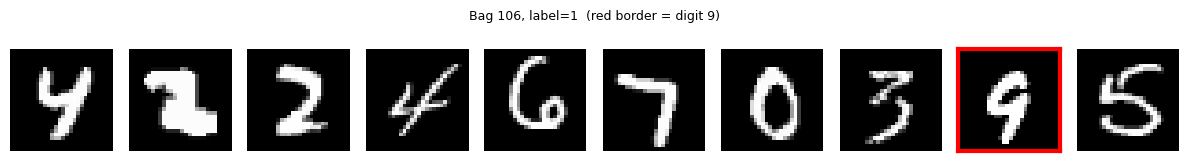

In [7]:
# get a random positive bag
_pos_idx = [i for i, (_, lbl, _) in enumerate(train_ds) if lbl == 1]    # indices of all positive bags
_idx     = int(np.random.default_rng().choice(_pos_idx))                # select a random positive bag index
bag, bag_label, inst_labels = train_ds[_idx]

# print some information about the bag
print(f"Bag index : {_idx}")
print(f"Bag size  : {bag.shape[0]} instances")
print(f"Bag label : {bag_label}  ({'positive' if bag_label else 'negative'})")
print(f"Target (9): {inst_labels.sum().item()} / {len(inst_labels)} instances")

# visualize the bag
n = bag.shape[0]
fig, axes = plt.subplots(1, n, figsize=(n * 1.2, 1.6))
if n == 1:
    axes = [axes]
for ax, img, is_target in zip(axes, bag, inst_labels):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        if is_target:
            spine.set_edgecolor("red")
            spine.set_linewidth(3)
        else:
            spine.set_visible(False)
plt.suptitle(f"Bag {_idx}, label={bag_label}  (red border = digit 9)", fontsize=9)
plt.tight_layout()
plt.show()

### Dataset Statistics

Here we do some data exploration to check the statistics of the generated datasets.

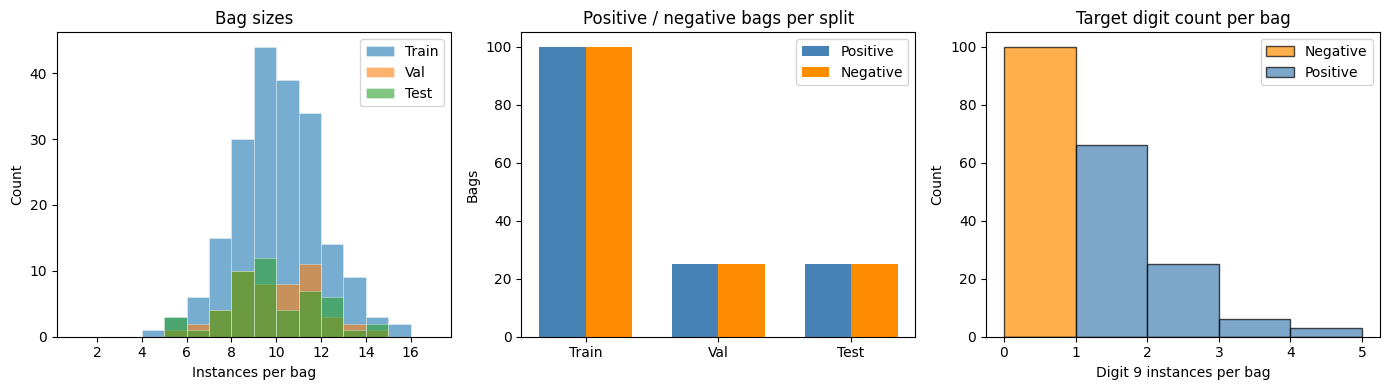

Bag length: mean=9.6  std=1.9  min=4  max=15
Train: 100/200 positive  (50%)
Val  : 25/50 positive  (50%)
Test : 25/50 positive  (50%)


In [9]:
splits = [("Train", train_ds), ("Val", val_ds), ("Test", test_ds)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
for split_name, ds in splits:
    sizes = [bag.shape[0] for bag, _, _ in ds]
    ax.hist(sizes, bins=range(1, 18), alpha=0.6, label=split_name,
            edgecolor='white', linewidth=0.4)
ax.set_xlabel("Instances per bag")
ax.set_ylabel("Count")
ax.set_title("Bag sizes")
ax.legend()

ax = axes[1]
x = np.arange(3)
pos_counts = [sum(ds._bag_labels) for _, ds in splits]
neg_counts  = [len(ds) - p for (_, ds), p in zip(splits, pos_counts)]
w = 0.35
ax.bar(x - w/2, pos_counts, w, label="Positive", color="steelblue")
ax.bar(x + w/2, neg_counts, w, label="Negative", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels([s for s, _ in splits])
ax.set_ylabel("Bags")
ax.set_title("Positive / negative bags per split")
ax.legend()

ax = axes[2]
pos_counts_hist = [inst_labels.sum().item() for _, lbl, inst_labels in train_ds if lbl == 1]
neg_counts_hist = [inst_labels.sum().item() for _, lbl, inst_labels in train_ds if lbl == 0]
max_count = max(pos_counts_hist)
bins = range(0, max_count + 2)
ax.hist(neg_counts_hist, bins=bins, alpha=0.7, label="Negative", color="darkorange", edgecolor='black')
ax.hist(pos_counts_hist, bins=bins, alpha=0.7, label="Positive", color="steelblue", edgecolor='black')
ax.set_xlabel(f"Digit {TARGET_NUMBER} instances per bag")
ax.set_ylabel("Count")
ax.set_title("Target digit count per bag")
ax.legend()

plt.tight_layout()
plt.show()

sizes_train = [bag.shape[0] for bag, _, _ in train_ds]
print(f"Bag length: mean={np.mean(sizes_train):.1f}  std={np.std(sizes_train):.1f}  "
      f"min={min(sizes_train)}  max={max(sizes_train)}")
for name, ds in splits:
    n_pos = sum(ds._bag_labels)
    print(f"{name:5s}: {n_pos}/{len(ds)} positive  ({100*n_pos/len(ds):.0f}%)")


## Model

We use a small CNN encoder (two convolutional layers followed by a fully connected layer) that maps each 28x28 patch to a 500-dimensional feature vector. The feature vectors are aggregated via one of three strategies: mean pooling, max pooling, or gated attention (ABMIL). The aggregated bag-level representation is then passed through a linear classifier to generate the final prediction. While the original Ilse et al. (2018) paper used only the attention-based aggregator, we also implement mean and max pooling for comparison.

In [10]:
class MnistEncoder(nn.Module):
    """Small CNN encoder for 28x28 greyscale images.

    Architecture taken from the ABMIL implementation (Ilse et al. 2018):
      Conv(1->20, k=5) -> ReLU -> MaxPool(2)
      Conv(20->50, k=5) -> ReLU -> MaxPool(2)
      Linear(800->500) -> ReLU

    Input:  (N, 1, 28, 28)
    Output: (N, 500)
    """

    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 20, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),
            nn.Conv2d(20, 50, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),
        )
        self.fc = nn.Sequential(
            nn.Linear(50 * 4 * 4, 500),
            nn.ReLU(),
        )

    def forward(self, x):    # (N, 1, 28, 28)
        x = self.conv(x)            # (N, 50, 4, 4)
        x = x.flatten(start_dim=1)  # (N, 800)
        return self.fc(x)           # (N, 500)


class MeanPoolAggregator(nn.Module):
    """Element-wise mean over instance features."""

    def forward(self, h):                         # (N, L)
        return h.mean(dim=0, keepdim=True), None  # (1, L), None


class MaxPoolAggregator(nn.Module):
    """Element-wise max over instance features."""

    def forward(self, h):                                  # (N, L)
        return h.max(dim=0, keepdim=True).values, None     # (1, L), None


class AttentionAggregator(nn.Module):
    """Gated attention aggregator (Ilse et al., ICML 2018).

    Attention score per instance:
        a_i = softmax( w^T ( tanh(V h_i) o s(U h_i) ) )

    Bag representation:
        z = sum_i a_i h_i

    Args:
        L: input feature dimension (must match encoder output)
        D: internal attention dimension
    """

    def __init__(self, L: int = 500, D: int = 128):
        super().__init__()
        self.V = nn.Linear(L, D)
        self.U = nn.Linear(L, D)
        self.w = nn.Linear(D, 1)

    def forward(self, h):                                           # (N, L)
        a = self.w(torch.tanh(self.V(h)) * torch.sigmoid(self.U(h)))  # (N, 1)
        a = torch.softmax(a, dim=0)                                 # (N, 1)
        z = (a * h).sum(dim=0, keepdim=True)                        # (1, L)
        return z, a.squeeze(1)                                      # (1, L), (N,)


class MILModel(nn.Module):
    """Encoder + aggregator + binary bag classifier.

    Always returns (logit, attention_weights), where attention_weights is None
    for non-adaptive aggregators (mean / max pooling).

    Args:
        encoder:    Instance-level feature extractor.
        aggregator: One of MeanPoolAggregator, MaxPoolAggregator, AttentionAggregator.
        feat_dim:   Dimensionality of encoder output (default 500).
    """

    def __init__(self, encoder: nn.Module, aggregator: nn.Module, feat_dim: int = 500):
        super().__init__()
        self.encoder    = encoder
        self.aggregator = aggregator
        self.classifier = nn.Linear(feat_dim, 1)

    def forward(self, bag):                     # (N, 1, 28, 28)
        h          = self.encoder(bag)          # (N, feat_dim)
        z, weights = self.aggregator(h)         # (1, feat_dim), (N,) or None
        logit      = self.classifier(z).squeeze()  # scalar
        return logit, weights

In [11]:
# check the output shapes for all three aggregators
models = [
    ("mean", MeanPoolAggregator()),
    ("max",  MaxPoolAggregator()),
    ("attn", AttentionAggregator())
]
bag = torch.randn(7, 1, 28, 28)

for name, agg in models:
    
    model  = MILModel(MnistEncoder(), agg)
    logit, weights = model(bag)
    w_shape = tuple(weights.shape) if weights is not None else None
    print(f"{name:4s}  logit={tuple(logit.shape)}  weights={w_shape}")

mean  logit=()  weights=None
max   logit=()  weights=None
attn  logit=()  weights=(7,)


## Training
We follow the training implementation of Ilse et al. (2018) with one change: instead of training for a fixed number of epochs, we use early stopping on validation loss (patience=10, min_delta=1e-3) to prevent overfitting.

In [12]:
# implement early stopping
# adapted from https://stackoverflow.com/a/73704579
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best      = float('inf')

    def step(self, val_loss):
        if val_loss < (self.best - self.min_delta):
            self.best    = val_loss
            self.counter = 0
            return False          # keep training
        self.counter += 1
        return self.counter >= self.patience  # True => stop


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for bag, label, _ in loader:
        bag   = bag.squeeze(0).to(device)
        label = label.float().squeeze().to(device)
        optimizer.zero_grad()
        logit, _ = model(bag)
        loss = criterion(logit, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def compute_val_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for bag, label, _ in loader:
            bag   = bag.squeeze(0).to(device)
            label = label.float().squeeze().to(device)
            logit, _ = model(bag)
            total_loss += criterion(logit, label).item()
    return total_loss / len(loader)


def evaluate(model, loader, device):
    """Returns AUC on the given loader."""
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for bag, label, _ in loader:
            bag = bag.squeeze(0).to(device)
            logit, _ = model(bag)
            probs.append(torch.sigmoid(logit).item())
            labels.append(label.item())
    return roc_auc_score(labels, probs)


def plot_confusion_matrix(model, loader, device, name):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for bag, label, _ in loader:
            bag = bag.squeeze(0).to(device)
            logit, _ = model(bag)
            preds.append((torch.sigmoid(logit) > 0.5).int().item())
            labels.append(label.item())
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Neg', 'Pos'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Neg', 'Pos'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{name} confusion matrix')
    plt.tight_layout()
    plt.show()

Here, the models are trained on a binary cross-entropy loss on the bag-level predictions. This may take a while! You can skip this cell if you have the model weights in `checkpoints/`.

mean:   0%|          | 0/200 [00:00<?, ?it/s]

  Early stopping at epoch 18


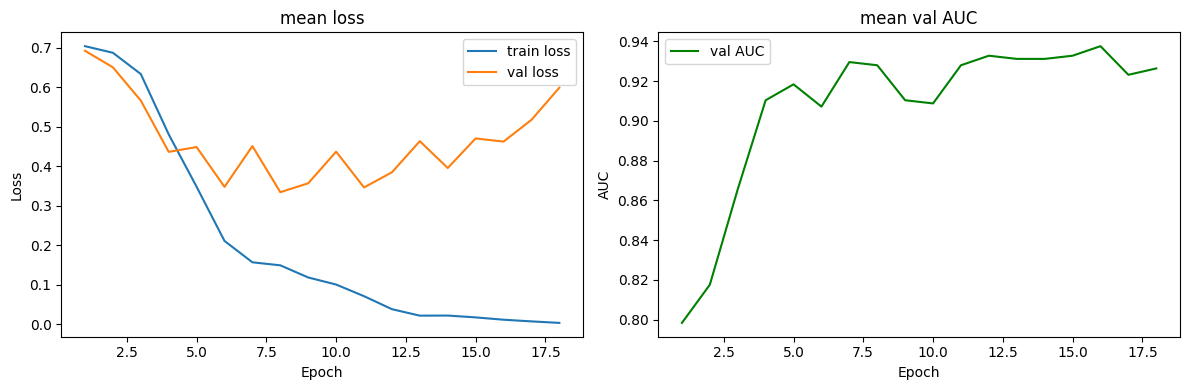

max:   0%|          | 0/200 [00:00<?, ?it/s]

  Early stopping at epoch 16


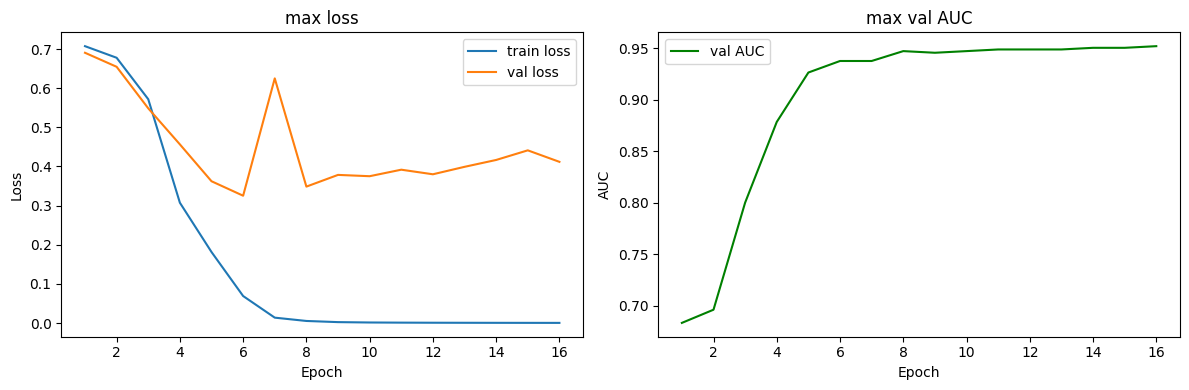

attn:   0%|          | 0/200 [00:00<?, ?it/s]

  Early stopping at epoch 16


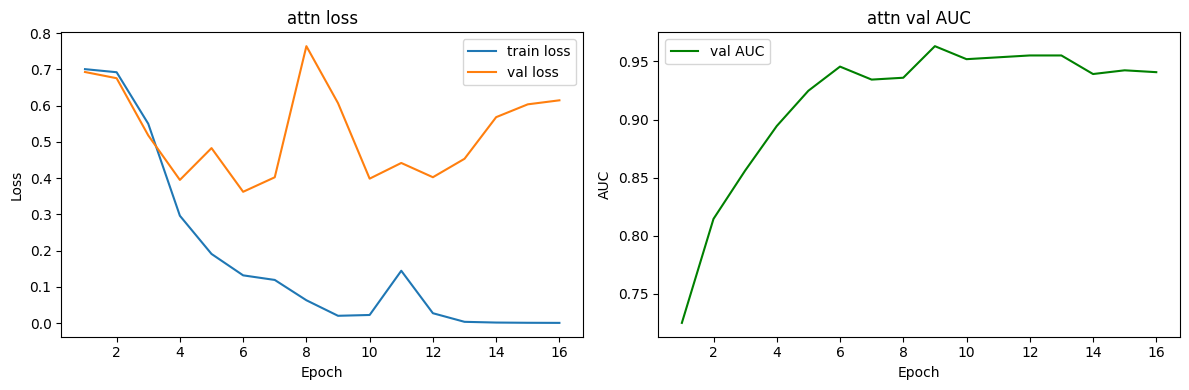


Summary (test set)
  mean  AUC=0.9472


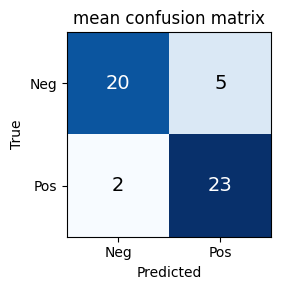

  max   AUC=0.9904


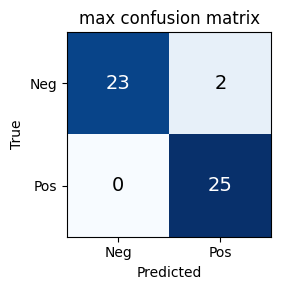

  attn  AUC=0.9728


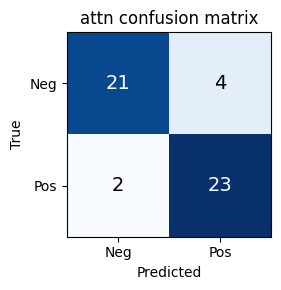

In [13]:
criterion = nn.BCEWithLogitsLoss()

configs = {
    "mean": MeanPoolAggregator(),
    "max":  MaxPoolAggregator(),
    "attn": AttentionAggregator(),
}

trained_models = {}

for name, agg in configs.items():
    model     = MILModel(MnistEncoder(), agg).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    stopper   = EarlyStopper(patience=EARLY_STOPPING_PATIENCE, min_delta=1e-3)

    train_losses, val_losses, val_aucs = [], [], []
    best_state = None

    pbar = tqdm(range(1, EPOCHS + 1), desc=name, leave=True)
    for epoch in pbar:
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss   = compute_val_loss(model, val_loader, criterion, DEVICE)
        val_auc    = evaluate(model, val_loader, DEVICE)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_aucs.append(val_auc)

        if val_loss <= stopper.best:
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        should_stop = stopper.step(val_loss)
        pbar.set_postfix(tr=f'{train_loss:.3f}', val=f'{val_loss:.3f}',
                         auc=f'{val_auc:.3f}', es=f'{stopper.counter}/{stopper.patience}')
        if should_stop:
            print(f"  Early stopping at epoch {epoch}")
            break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

    epochs_ran = range(1, len(train_losses) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs_ran, train_losses, label='train loss')
    ax1.plot(epochs_ran, val_losses,   label='val loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{name} loss'); ax1.legend()
    ax2.plot(epochs_ran, val_aucs, color='green', label='val AUC')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')
    ax2.set_title(f'{name} val AUC'); ax2.legend()
    plt.tight_layout(); plt.show()

    torch.save(model.state_dict(), f"{CKPT_DIR}/mnist_{name}.pt")
    trained_models[name] = model

print("\nSummary (test set)")
for name, model in trained_models.items():
    test_auc = evaluate(model, test_loader, DEVICE)
    print(f"  {name:4s}  AUC={test_auc:.4f}")
    plot_confusion_matrix(model, test_loader, DEVICE, name)

In [24]:
# load trained checkpoints to skip retraining after a kernel restart
trained_models = {}
for name, agg in [("mean", MeanPoolAggregator()),
                  ("max",  MaxPoolAggregator()),
                  ("attn", AttentionAggregator())]:
    model = MILModel(MnistEncoder(), agg).to(DEVICE)
    model.load_state_dict(torch.load(f"{CKPT_DIR}/mnist_{name}.pt", weights_only=True))
    model.eval()
    trained_models[name] = model
    print(f"Loaded  {name}")

Loaded  mean
Loaded  max
Loaded  attn


In [25]:
# re-run after a kernel restart to restore analysis state without retraining

attn_model = trained_models["attn"]
attn_model.eval()

_MEAN_T = torch.tensor([0.1307])
_STD_T  = torch.tensor([0.3081])

def denorm(t):
    return (t * _STD_T + _MEAN_T).clamp(0, 1)

pos_indices = [i for i, (_, lbl, _) in enumerate(test_ds) if lbl == 1]
chosen = np.random.default_rng(SEED).choice(
    pos_indices, size=min(4, len(pos_indices)), replace=False
)

## Results

Finally, we test the trained models on the test set and generate some visualizations to better understand the models predictions. The attention-based model achieves the highest AUC, as expected, but all three models perform quite well on this task.

### ROC Curves

mean   AUC = 0.9792
max    AUC = 0.9760
attn   AUC = 0.9920


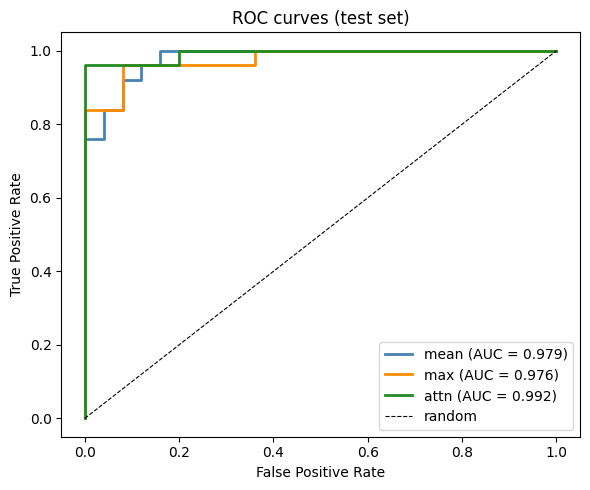

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = {"mean": "steelblue", "max": "darkorange", "attn": "forestgreen"}

for name, model in trained_models.items():
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for bag, label, _ in test_loader:
            bag = bag.squeeze(0).to(DEVICE)
            logit, _ = model(bag)
            probs.append(torch.sigmoid(logit).item())
            labels.append(label.item())
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=colors[name], linewidth=2)
    print(f"{name:6s} AUC = {auc:.4f}")

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves (test set)")
ax.legend()
plt.tight_layout()
plt.show()

### Instance-Level AUC
Here, we treat each instance's attention weight as a proxy score for "is this a 9?" and compute the AUC against the true per-instance labels across all test bags. A score of 0.9353 across 467 instances (34 positive, 433 negative) shows that the model correctly focuses its attention on the target digit 9.

In [27]:
inst_labels_all, inst_attn_all = [], []

attn_model.eval()
with torch.no_grad():
    for bag, _, inst_labels in test_ds:
        h = attn_model.encoder(bag.to(DEVICE))
        _, attn_w = attn_model.aggregator(h)
        inst_labels_all.append(inst_labels.numpy())  # True where the instance is a 9
        inst_attn_all.append(attn_w.cpu().numpy())   # attention weight per instance

# flatten across all bags into two parallel arrays
inst_labels  = np.concatenate(inst_labels_all).astype(int)
attn_scores  = np.concatenate(inst_attn_all)

# AUC between attention scores and true instance labels
inst_auc = roc_auc_score(inst_labels, attn_scores)
n_pos = inst_labels.sum()
n_neg = len(inst_labels) - n_pos
print(f"AUC: {inst_auc:.4f}")
print(f"{n_pos} positive instances,  {n_neg} negative  ({len(inst_labels)} total)")

AUC: 0.9353
34 positive instances,  433 negative  (467 total)


### Attention Visualisation

Next, we look at the attention weights for some positive test bags. We should expect the model to assign high attention to instances of the digit 9.

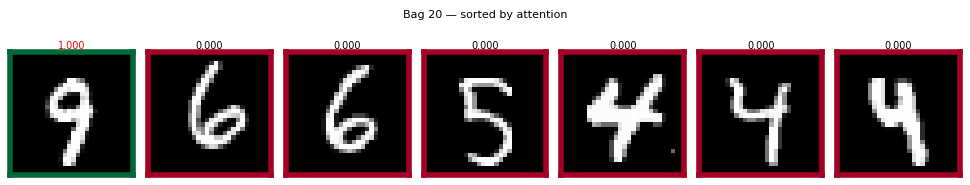

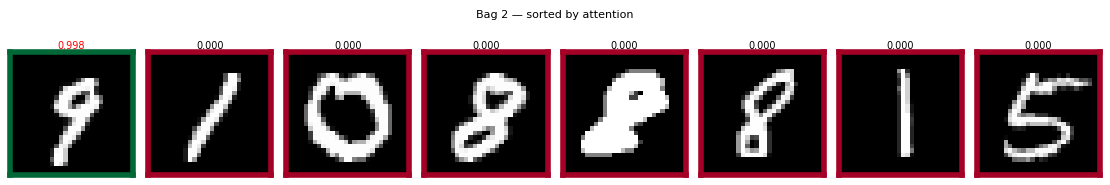

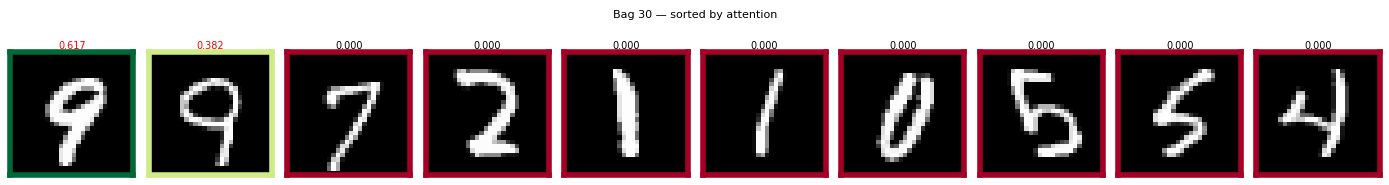

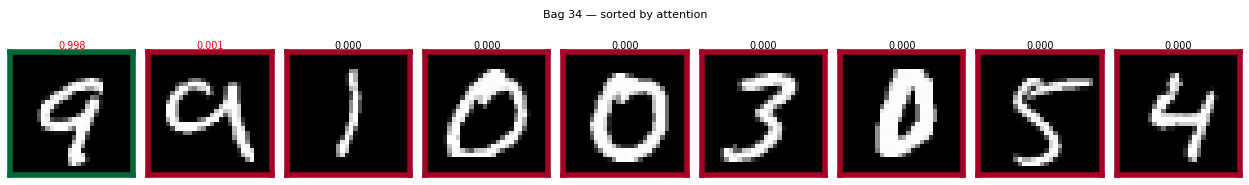

In [28]:
cmap = plt.cm.RdYlGn

for idx in chosen:
    bag, _, inst_labels = test_ds[idx]

    with torch.no_grad():
        h = attn_model.encoder(bag.to(DEVICE))
        _, attn = attn_model.aggregator(h)

    attn = attn.cpu().numpy()
    order       = np.argsort(attn)[::-1].copy()
    attn_sorted = attn[order]
    imgs_sorted = bag[order]
    is9_sorted  = inst_labels.numpy()[order]
    attn_norm   = (attn_sorted - attn_sorted.min()) / (attn_sorted.max() - attn_sorted.min() + 1e-8)

    n = len(order)
    fig, axes = plt.subplots(1, n, figsize=(n * 1.4, 1.9))
    if n == 1:
        axes = [axes]

    for i, (ax, img, is9) in enumerate(zip(axes, imgs_sorted, is9_sorted)):
        ax.imshow(denorm(img).squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(cmap(attn_norm[i]))
            spine.set_linewidth(4)
        ax.set_title(f"{attn_sorted[i]:.3f}", fontsize=7,
                     color="red" if is9 else "black", pad=2)

    plt.suptitle(f"Bag {idx} — sorted by attention", fontsize=8)
    plt.tight_layout()
    plt.show()

### Top-Attended Instance per Positive Bag

For every positive test bag, we take the single instance with the highest attention weight and display it. A well trained model should show mostly 9s here.

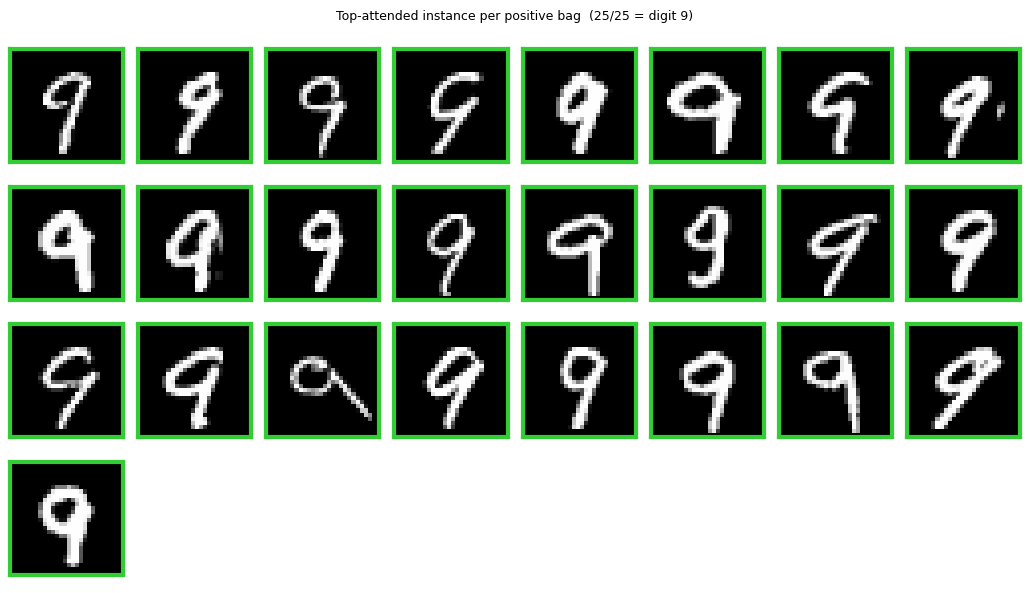

In [30]:
top_imgs, top_correct = [], []

attn_model.eval()
with torch.no_grad():
    for bag, label, inst_labels in test_ds:
        if label != 1:
            continue
        h = attn_model.encoder(bag.to(DEVICE))
        _, attn = attn_model.aggregator(h)
        best = attn.argmax().item()
        top_imgs.append(denorm(bag[best]))
        top_correct.append(bool(inst_labels[best]))

n      = len(top_imgs)
cols   = 8
rows   = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.3, rows * 1.5))
axes = np.array(axes).flatten()

for ax, img, correct in zip(axes, top_imgs, top_correct):
    ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    color = "limegreen" if correct else "red"
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

for ax in axes[n:]:
    ax.axis("off")

n_correct = sum(top_correct)
plt.suptitle(f"Top-attended instance per positive bag  ({n_correct}/{n} = digit 9)", fontsize=9)
plt.tight_layout()
plt.show()

### t-SNE of Encoder Features

We run all test-set instances through the CNN encoder of the ABMIL model to get their 500-dimensional feature representations. We then plot them via t-SNE, such that different digits have different colors. A well trained model should cluster instances of the target digit 9 away from the rest of instances in feature space, and the attention scores should also be concentrated in the cluster of 9s.

Running t-SNE on 467 instances...


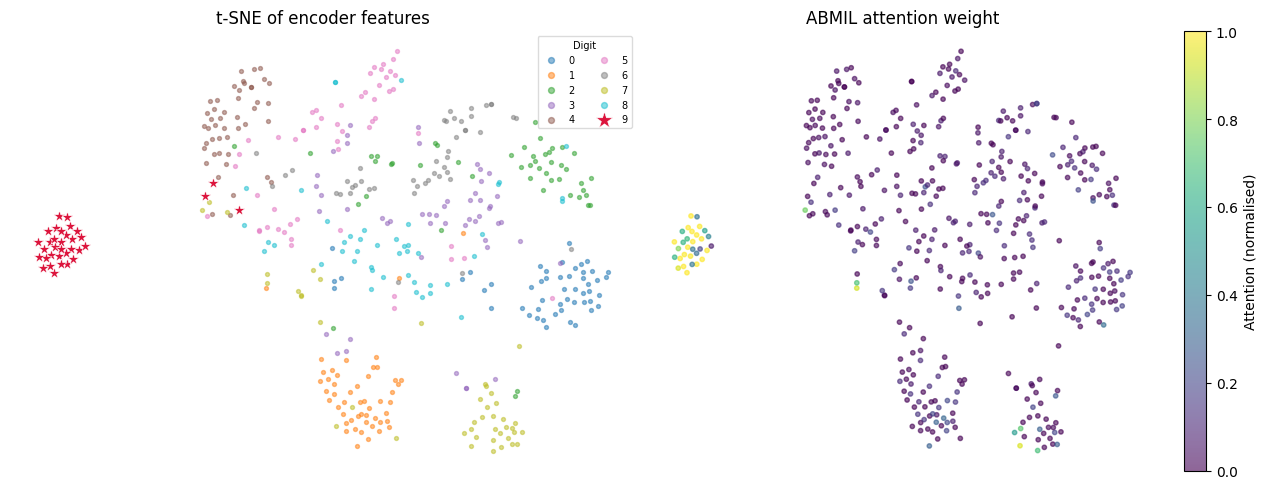

In [34]:
all_feats, all_digits, all_attn = [], [], []

# get encoder features, the true digit labels and the attention weights for all instances in the test set
attn_model.eval()
with torch.no_grad():
    for i, (bag, _, _) in enumerate(test_ds):
        h = attn_model.encoder(bag.to(DEVICE))
        _, attn = attn_model.aggregator(h)
        all_feats.append(h.cpu())
        all_digits.append(test_ds._instance_digit_labels[i])
        all_attn.append(attn.cpu())

feats  = torch.cat(all_feats).numpy()
digits = torch.cat(all_digits).numpy()
attn   = torch.cat(all_attn).numpy()

# a boolean mask for the target digit
is9    = digits == TARGET_NUMBER

print(f"Running t-SNE on {len(feats)} instances...")

# generate the t-SNE visualization of the encoder features
coords = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(feats)

# get some non red colors (so we can use red for 9)
_tab = plt.cm.tab10.colors
_non9 = [_tab[i] for i in [0, 1, 2, 4, 5, 6, 7, 8, 9]]

# normalise attention scores to [0, 1]
attn_norm = (attn - attn.min()) / (attn.max() - attn.min() + 1e-10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# show all digits in a different color
for d in range(9):
    mask = digits == d
    if mask.any():
        ax1.scatter(coords[mask, 0], coords[mask, 1],
                    color=_non9[d], s=8, alpha=0.5, marker='o', label=str(d))

# highlight the target digit with red stars, and white edges to make them more visible
ax1.scatter(coords[is9, 0], coords[is9, 1],
            color='crimson', s=70, alpha=1.0,
            marker='*', edgecolors='white', linewidths=0.4,
            zorder=5, label='9')

ax1.set_title("t-SNE of encoder features")
ax1.legend(title="Digit", fontsize=7, title_fontsize=7,
           markerscale=1.5, ncol=2, loc='best', framealpha=0.7)
ax1.axis("off")

# on the right side, we show a visualization of the attention weight for each instance
sc = ax2.scatter(coords[:, 0], coords[:, 1], c=attn_norm,
                 cmap="viridis", vmin=0, vmax=1, s=10, alpha=0.6)
plt.colorbar(sc, ax=ax2, label="Attention (normalised)")
ax2.set_title("ABMIL attention weight")
ax2.axis("off")

plt.tight_layout()
plt.show()

### Filter Activation Analysis

Next, we look at the filters in the convolutional layers `conv1` and `conv2` of the CNN encoder. We can compute the receptive field of each filter to understand what kind of features they are capturing. Interestingly, we often see the same lower line segment of the digit 9 repeated in the `conv2` filters, which indicates some overfitting. Overall, it looks like the model is mostly using its filters to recognize specific parts of the digit 9, which confirms that it has correctly learned to focus on the target digit.

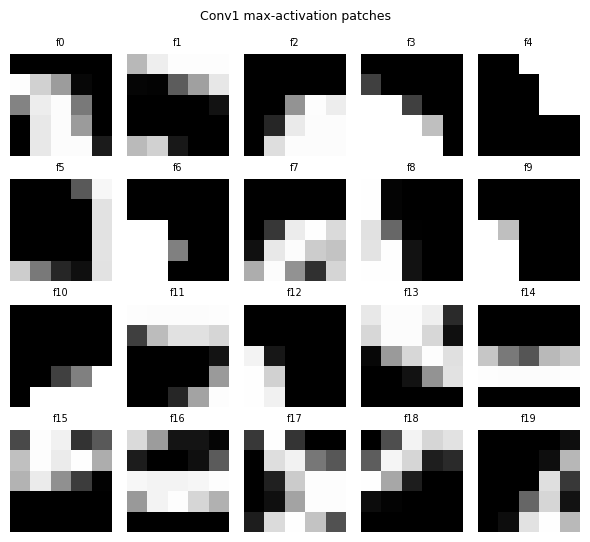

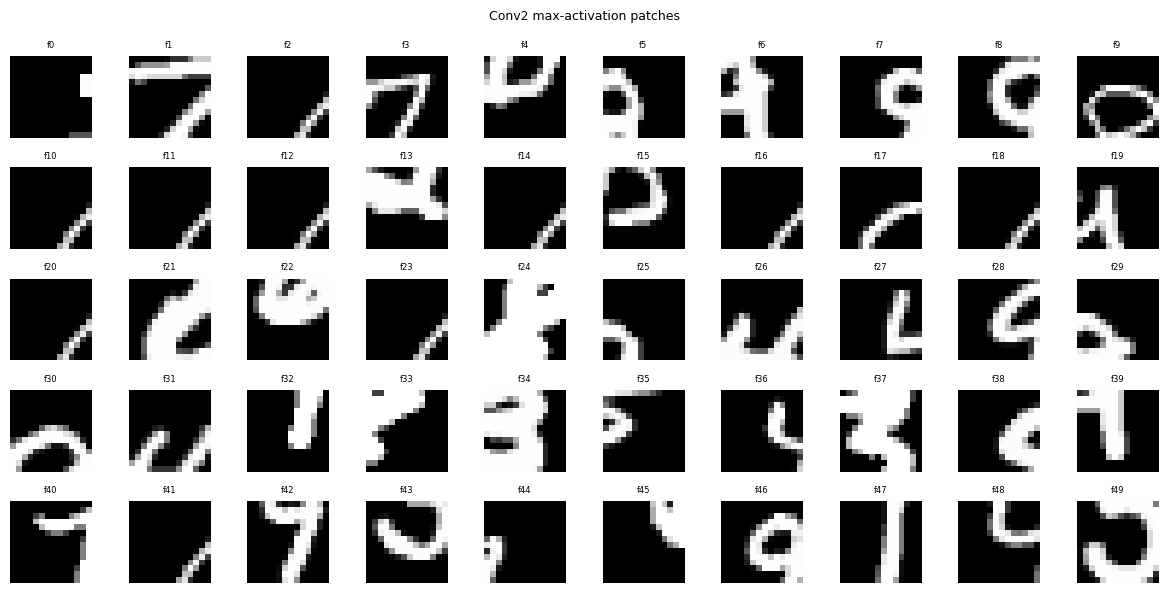

In [35]:
all_imgs_list, all_act1_list, all_act2_list = [], [], []

attn_model.eval()
with torch.no_grad():
    for bag, _, _ in test_ds:
        x  = bag.to(DEVICE)
        a1 = torch.relu(attn_model.encoder.conv[0](x))        # (N, 20, 24, 24)
        xp = attn_model.encoder.conv[2](a1)                    # (N, 20, 12, 12)
        a2 = torch.relu(attn_model.encoder.conv[3](xp))       # (N, 50,  8,  8)
        all_imgs_list.append(bag)
        all_act1_list.append(a1.cpu())
        all_act2_list.append(a2.cpu())

imgs_all = torch.cat(all_imgs_list)   # (M, 1, 28, 28)
act1_all = torch.cat(all_act1_list)   # (M, 20, 24, 24)
act2_all = torch.cat(all_act2_list)   # (M, 50,  8,  8)

# conv1 output position (h, w) maps to input pixels [h:h+5, w:w+5]
patches1 = []
for f in range(20):
    act_f = act1_all[:, f]
    flat  = act_f.reshape(-1).argmax().item()
    M_, H_, W_ = act_f.shape
    img_i = flat // (H_ * W_)
    sp    = flat %  (H_ * W_)
    h, w  = sp // W_, sp % W_
    patches1.append(denorm(imgs_all[img_i])[:, h:h+5, w:w+5].squeeze().numpy())

fig, axes = plt.subplots(4, 5, figsize=(6, 5.5))
for ax, patch, f in zip(axes.flat, patches1, range(20)):
    ax.imshow(patch, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(f"f{f}", fontsize=7)
    ax.axis('off')
plt.suptitle("Conv1 max-activation patches", fontsize=9)
plt.tight_layout()
plt.show()

# conv2 output (h, w) maps to input rows [2h:2h+14], cols [2w:2w+14]
patches2 = []
for f in range(50):
    act_f = act2_all[:, f]
    flat  = act_f.reshape(-1).argmax().item()
    M_, H_, W_ = act_f.shape
    img_i = flat // (H_ * W_)
    sp    = flat %  (H_ * W_)
    h, w  = sp // W_, sp % W_
    r0, c0 = 2 * h, 2 * w
    patches2.append(denorm(imgs_all[img_i])[:, r0:r0+14, c0:c0+14].squeeze().numpy())

fig, axes = plt.subplots(5, 10, figsize=(12, 6))
for ax, patch, f in zip(axes.flat, patches2, range(50)):
    ax.imshow(patch, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(f"f{f}", fontsize=6)
    ax.axis('off')
plt.suptitle("Conv2 max-activation patches", fontsize=9)
plt.tight_layout()
plt.show()

### Misclassified Bags

Finally, we inspect some test bags that the ABMIL model has predicted incorrectly.

Total false positives: 1
Total false negatives: 1

False positives


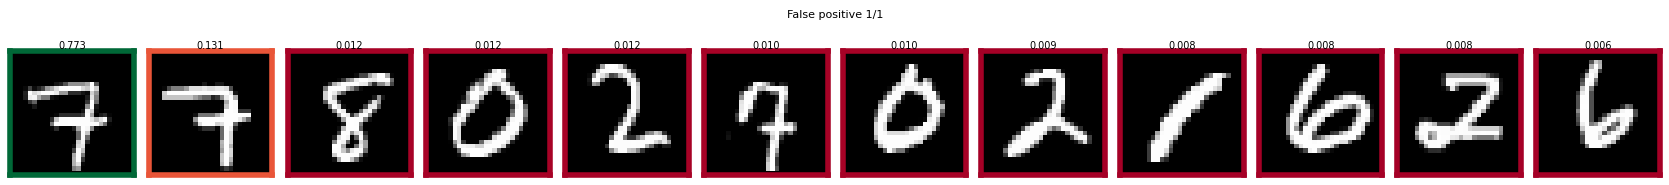


False negatives


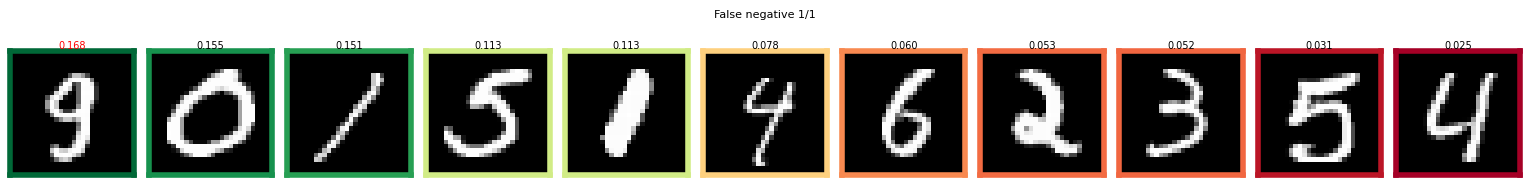

In [38]:
attn_model.eval()
fp_bags, fn_bags = [], []

with torch.no_grad():
    for bag, label, inst_labels in test_ds:
        logit, attn_w = attn_model(bag.to(DEVICE))
        pred = int(torch.sigmoid(logit) > 0.5)
        if pred == 1 and label == 0:
            fp_bags.append((bag, inst_labels, attn_w.cpu().numpy()))
        elif pred == 0 and label == 1:
            fn_bags.append((bag, inst_labels, attn_w.cpu().numpy()))

print(f"Total false positives: {len(fp_bags)}")
print(f"Total false negatives: {len(fn_bags)}")

def show_bag_with_attn(bag, inst_labels, attn_w, title):
    order       = np.argsort(attn_w)[::-1].copy()
    attn_sorted = attn_w[order]
    imgs_sorted = bag[order]
    is9_sorted  = inst_labels.numpy()[order]
    attn_norm   = (attn_sorted - attn_sorted.min()) / (attn_sorted.max() - attn_sorted.min() + 1e-8)
    n = len(order)
    fig, axes = plt.subplots(1, n, figsize=(n * 1.4, 1.9))
    if n == 1:
        axes = [axes]
    for i, (ax, img, is9) in enumerate(zip(axes, imgs_sorted, is9_sorted)):
        ax.imshow(denorm(img).squeeze(), cmap='gray', vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(plt.cm.RdYlGn(attn_norm[i]))
            spine.set_linewidth(4)
        ax.set_title(f"{attn_sorted[i]:.3f}", fontsize=7,
                     color='red' if is9 else 'black', pad=2)
    plt.suptitle(title, fontsize=8)
    plt.tight_layout()
    plt.show()

MAX_SHOW = 3

if fp_bags:
    print(f"\nFalse positives")
    for i, (bag, inst_labels, attn_w) in enumerate(fp_bags[:MAX_SHOW]):
        show_bag_with_attn(bag, inst_labels, attn_w,
            f"False positive {i+1}/{len(fp_bags)}")

if fn_bags:
    print(f"\nFalse negatives")
    for i, (bag, inst_labels, attn_w) in enumerate(fn_bags[:MAX_SHOW]):
        show_bag_with_attn(bag, inst_labels, attn_w,
            f"False negative {i+1}/{len(fn_bags)}")